# ACC102 Track2: 科技股月度收益分析

**数据来源**：WRDS CRSP月度股票数据（2025年）
**分析标的**：AAPL、MSFT、GOOGL
**分析内容**：
- 累计收益走势对比
- 年化波动率计算
- 平均月收益率分析

数据预览：
Ticker        AAPL   GOOGL    MSFT
MthCalDt                          
2025-01-31  236.00  204.02  415.06
2025-02-28  241.84  170.28  396.99
2025-03-31  222.13  154.64  375.39
2025-04-30  212.50  158.80  395.26
2025-05-30  200.85  171.74  460.36


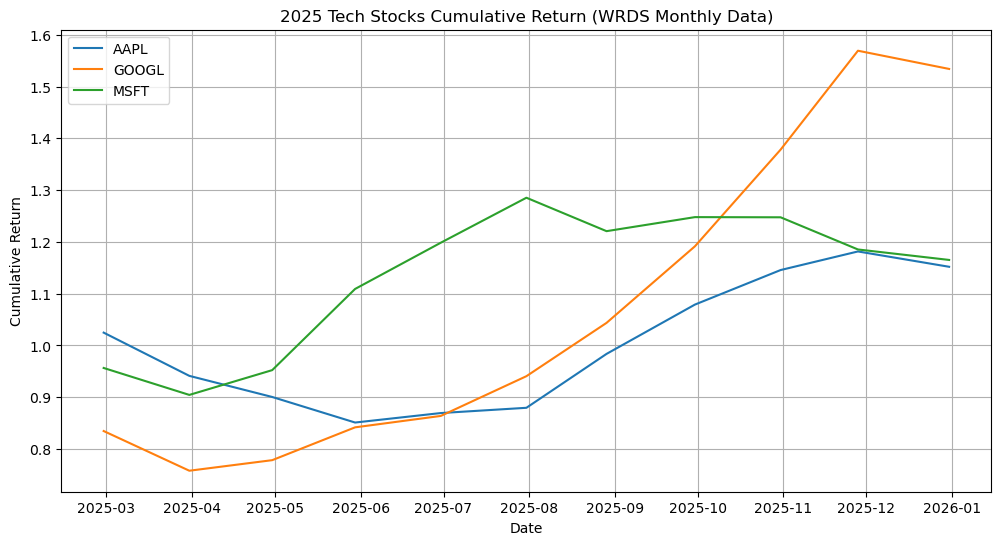


==== 年化波动率 ====
Ticker
AAPL     0.216872
GOOGL    0.357066
MSFT     0.243604
dtype: float64

==== 平均月收益率 ====
Ticker
AAPL     0.014694
GOOGL    0.044584
MSFT     0.016141
dtype: float64


In [9]:
import pandas as pd
from io import StringIO
import matplotlib.pyplot as plt

csv_data = """PERMNO,HdrCUSIP,Ticker,PERMCO,MthCalDt,MthPrc
10107,59491810,MSFT,8048,2025-01-31,415.060000
14593,03783310,AAPL,7,2025-01-31,236.000000
90319,02079K30,GOOGL,45483,2025-01-31,204.020000
10107,59491810,MSFT,8048,2025-02-28,396.990000
14593,03783310,AAPL,7,2025-02-28,241.840000
90319,02079K30,GOOGL,45483,2025-02-28,170.280000
10107,59491810,MSFT,8048,2025-03-31,375.390000
14593,03783310,AAPL,7,2025-03-31,222.130000
90319,02079K30,GOOGL,45483,2025-03-31,154.640000
10107,59491810,MSFT,8048,2025-04-30,395.260000
14593,03783310,AAPL,7,2025-04-30,212.500000
90319,02079K30,GOOGL,45483,2025-04-30,158.800000
10107,59491810,MSFT,8048,2025-05-30,460.360000
14593,03783310,AAPL,7,2025-05-30,200.850000
90319,02079K30,GOOGL,45483,2025-05-30,171.740000
10107,59491810,MSFT,8048,2025-06-30,497.410000
14593,03783310,AAPL,7,2025-06-30,205.170000
90319,02079K30,GOOGL,45483,2025-06-30,176.230000
10107,59491810,MSFT,8048,2025-07-31,533.500000
14593,03783310,AAPL,7,2025-07-31,207.570000
90319,02079K30,GOOGL,45483,2025-07-31,191.900000
10107,59491810,MSFT,8048,2025-08-29,506.690000
14593,03783310,AAPL,7,2025-08-29,232.140000
90319,02079K30,GOOGL,45483,2025-08-29,212.910000
10107,59491810,MSFT,8048,2025-09-30,517.950000
14593,03783310,AAPL,7,2025-09-30,254.630000
90319,02079K30,GOOGL,45483,2025-09-30,243.100000
10107,59491810,MSFT,8048,2025-10-31,517.810000
14593,03783310,AAPL,7,2025-10-31,270.370000
90319,02079K30,GOOGL,45483,2025-10-31,281.190000
10107,59491810,MSFT,8048,2025-11-28,492.010000
14593,03783310,AAPL,7,2025-11-28,278.850000
90319,02079K30,GOOGL,45483,2025-11-28,320.180000
10107,59491810,MSFT,8048,2025-12-31,483.620000
14593,03783310,AAPL,7,2025-12-31,271.860000
90319,02079K30,GOOGL,45483,2025-12-31,313.000000"""

df = pd.read_csv(StringIO(csv_data))

df['MthCalDt'] = pd.to_datetime(df['MthCalDt'])

data = df.pivot(index='MthCalDt', columns='Ticker', values='MthPrc')
data = data.dropna()

print("数据预览：")
print(data.head())

returns = data.pct_change()
cumulative_returns = (1 + returns).cumprod()

plt.figure(figsize=(12,6))
for col in cumulative_returns.columns:
    plt.plot(cumulative_returns.index, cumulative_returns[col], label=col)
plt.title("2025 Tech Stocks Cumulative Return (WRDS Monthly Data)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.show()

print("\n==== 年化波动率 ====")
print(returns.std() * (12 ** 0.5))  # 月度数据年化用12个月
print("\n==== 平均月收益率 ====")
print(returns.mean())